# VA DEQ & StreamStats Exploratory Data Analysis

The purpose of this notebook is to anaylze the VA DEQ & StreamStats datasets using as many visualizatons as possible.

Emma Reilly Oare

In [1]:
# Standard Libraries
import os 
import warnings 
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns 
import scipy.stats as stats 
from scipy.stats import f
import statsmodels.api as sm 
from dbfread import DBF
from scipy.optimize import curve_fit
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error

# Suppress warnings
warnings.filterwarnings("ignore")

In [2]:
# Show all columns
pd.set_option('display.max_columns', None) 

## Step 1. Import dataset

In [3]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [4]:
# Read in joined and cleaned excel sheet
vadeq_path = os.path.join(BASE_DIR, "data", "processed", "virginia", "vadeq_strmstats_mrgd.xlsx")
vadeq_strmsts = pd.read_excel(vadeq_path).drop(columns = ['Unnamed: 0'])

In [6]:
# Display datafram
vadeq_strmsts

,StationID,Date,ReachLength,Slope,RP100,BR_PCT,HP_PCT,RC_PCT,BL_PCT,CB_PCT,GC_PCT,GF_PCT,SA_PCT,FN_PCT,WD_PCT,OT_PCT,BL_CB_GR_PCT,SA_FN_PCT,TotSubstrate_PCT,LSUB_DMM,VLW_msq,Xdepth,Xwid,XBKF_W,BKF_depth_in_meters,BKFW_BKFD,incised_depth,Xembed,LRBS2,Year,Bankfull Shear Velocity (m/s),RELIEF,STATSCLY30,LC01IMP,STATSOM2_6,PDIGMET,LC06FORSHB,LC11GRASS,PKREGNO,BRMETA,STATSCLY40,PRECIP,STATSPERM,STATSCLY50,STATSCLY60,LC01DEV,LC06GRASS,LC06WATER,LC11IMP,STATSWATCP,I24H2Y,STATOM19_8,LC06CRPHAY,LC11WATER,LC06IMP,LC06DEV,LC11CRPHAY,LFREGNO,LC11DEV,LC01FORSHB,VRPLSLC,VRCARB,LC06WETLND,STATSGODEP,MINBELEV,LC11FORSHB,LC11WETLND,DRNAREA,LC01BARE,ELEV,LC11BARE,CPSED,LC01CRPHAY,STATSCLAY10,STATSCLY20,LC06BARE,LC01WATER,LC01HERB,STATSOM0_5,ELEVMAX,LC01WETLND,Shape_Length,Shape_Area,1 Day 1.11 Year Low Flow,1 Day 1.25 Year Low Flow,1 Day 1.43 Year Low Flow,1 Day 1.67 Year Low Flow,1 Day 2 Year Low Flow,10-percent AEP flood,2-percent AEP flood,20-percent AEP flood,30 Day 1.11 Year Low Flow,30 Day 1.25 Year Low Flow,30 Day 1.43 Year Low Flow,4 Day 1.11 Year Low Flow,4 Day 1.25 Year Low Flow,4-percent AEP flood,7 Day 1.11 Year Low Flow,7 Day 1.25 Year Low Flow,7 Day 1.43 Year Low Flow,7 Day 1.67 Year Low Flow,Bieger_D_channel_cross_sectional_area,Bieger_D_channel_depth,Bieger_D_channel_width,Bieger_USA_channel_cross_sectional_area,Bieger_USA_channel_depth,Bieger_USA_channel_width,Urban 0.2-percent AEP flood,Urban 0.5-percent AEP flood,Urban 1-percent AEP flood,Urban 10-percent AEP flood,Urban 2-percent AEP flood,Urban 20-Percent AEP flood,Urban 4-percent AEP flood,Urban 42.9-percent AEP flood,Urban 50-percent AEP flood,Urban 66.7-percent AEP flood,Urban 80-percent AEP flood,Urban 90-percent AEP flood,Urban 95-percent AEP flood,Urban 99-percent AEP flood,Urban 99.5-percent AEP flood,Month
0,1AACO006.10,2006-11-21,440,0.220,34.752500,7.692308,6.730769,0.000000,9.615385,14.423077,35.576923,6.730769,16.346154,2.884615,0.000000,0.0,66.346154,19.230769,100.0,1.582869,0.001897,66.12,14.690476,18.636364,1.123018,16.594890,2.547564,62.545455,0.517308,2006,0.147072,171.0,100.00,14.94,0.00,33.39,37.62,0.00,1551,0.0,0.00,43.078,2.895,0.00,0.00,57.04,0.00,0.00,19.30,0.000,3.140,0,0.00,0.00,14.20,56.93,0.00,1545,83.80,42.96,0.00,0.00,0.00,70.48,54.96,16.23,0.00,0.0702,0.00,148.98,0.00,66.61,0.00,0.0,0.00,5.45,0.00,0.00,100.00,225.47,0.00,2380,181800,0.012467,0.007940,0.005353,0.003673,0.002477,71.533333,166.366667,45.000000,0.039167,0.027933,0.020600,0.033533,0.024733,118.666667,0.041400,0.029733,0.022600,0.017200,2.66,0.523,5.05,4.07,0.685,4.86,426.333333,351.333333,293.666667,136.333333,219.666667,106.866667,167.333333,84.400000,78.800000,78.666667,65.633333,63.500000,54.8,64.933333,64.200000,11
1,1AACO004.84,2008-06-25,320,0.521,25.757012,0.000000,0.952381,0.000000,5.714286,27.619048,26.666667,14.285714,10.476190,7.619048,6.666667,0.0,74.285714,18.095238,100.0,1.165237,0.004859,56.22,9.580952,15.372727,0.989473,15.536282,2.275836,51.636364,-0.245939,2008,0.211670,451.0,48.13,21.97,0.00,87.78,25.10,0.01,1550,0.0,0.02,43.888,2.395,0.00,0.00,70.34,0.01,0.25,23.10,0.133,3.167,0,0.28,0.26,22.19,71.05,0.11,1544,73.50,25.82,0.00,0.00,3.27,66.65,39.50,22.49,3.50,40.5000,0.03,308.44,0.17,11.98,0.28,0.0,51.85,0.05,0.25,0.01,100.00,490.18,3.28,85900,105013700,6.723333,4.653333,3.446667,2.620000,1.960000,2853.333333,5380.000000,2009.333333,14.666667,10.523333,7.973333,9.220000,6.893333,4193.333333,11.246667,8.433333,6.696667,5.390000,233.00,3.240,70.60,126.00,2.650,45.60,31866.666667,17166.666667,12633.333333,5350.000000,9886.666667,3886.666667,8006.666667,2400.000000,2140.000000,1543.333333,1206.666667,891.000000,782.0,536.666667,487.666667,6
2,1AACO006.10,2008-06-26,520,0.173,35.429907,2.857143,7.619048,0.952381,4.761905,21.904762,22.857143,12.380952,20.952381,2.857143,2.857143,0.0,61.904762,23.809524,100.0,1.327436,0.000897,63.57,13.819048,17.800000,1.112973,15.993204,2.990245,56.818182,0.374672,2008,0.129573,171.0,100.00,14.94,0.00,33.39,37.62,0.00,1551,0.0,0.00,43

## Step 2. EDA

### Step 2a. Station embeddedness temporal variation
We will first need to check on stations that have been monitored for multiple years. **The VA DEQ assumed minimal variation for most sites across multiple visits**, so let's check before moving on.

In [7]:
# Identify the StationIDs that appear more than twice
stn_count = vadeq_strmsts['StationID'].value_counts()
mult_stn = stn_count[stn_count > 2].index
mult_stn_obj = stn_count[stn_count > 2]

# Create a filtered dataset to only include these StationIDs
multiyr_vdeq = vadeq_strmsts[vadeq_strmsts['StationID'].isin(mult_stn)]

# Check how many stations this encompasses
multiyr_vdeq.nunique()

StationID                        33
Date                            163
ReachLength                      13
Slope                           151
RP100                           171
                               ... 
Urban 90-percent AEP flood       33
Urban 95-percent AEP flood       33
Urban 99-percent AEP flood       33
Urban 99.5-percent AEP flood     33
Month                            10
Length: 123, dtype: int64

**Here we can see that 33 stations were visited more than twice (3 or greater times).**

In [8]:
# Turn multiple station series into a dataframe
mult_stn_df = mult_stn_obj.to_frame()

# Show df
mult_stn_df

,count
StationID,
2-TYE008.77,9
2-LIJ003.06,9
2-RED003.65,8
8-POR015.70,8
4ABAU011.17,8
2-HAM000.37,7
2-XVX000.62,7
4ABNN002.17,7
2BXRK001.64,7


Let's now check how many stations see significant change.

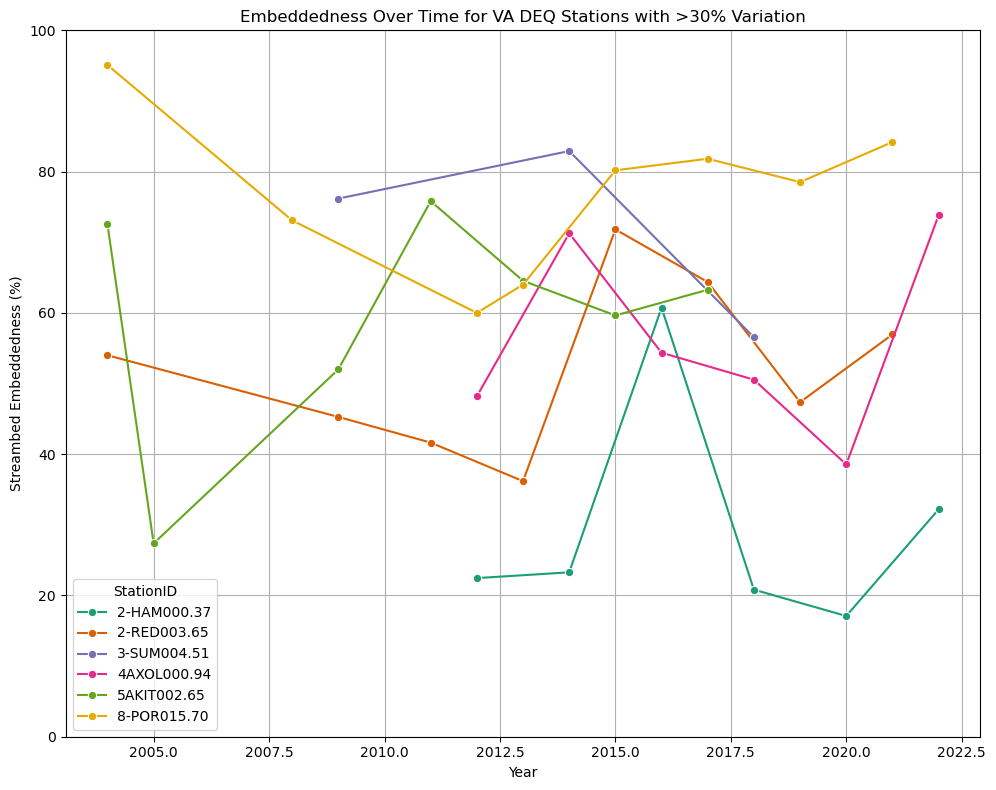

,StationID,min,max,Xembed_pct_change
25,5AKIT002.65,27.363636,75.818182,48.454545
4,2-HAM000.37,16.181818,60.727273,44.545455
8,2-RED003.65,36.181818,71.818182,35.636364
22,4AXOL000.94,38.545455,73.818182,35.272727
28,8-POR015.70,60.000000,95.090909,35.090909
16,3-SUM004.51,49.636364,83.909091,34.272727
10,2-TYE008.77,32.909091,62.909091,30.000000
12,2BXAE001.80,37.363636,67.272727,29.909091
6,2-LIJ003.06,31.090909,59.800000,28.709091
2,2-DCK003.94,21.090909,47.727273,26.636364


In [9]:
# Reset index
if 'StationID' in multiyr_vdeq.index.names:
    multiyr_vdeq.reset_index(inplace=True, drop=True)

# Calculate the minimum and maximum embeddedness values for each site
min_max_values = multiyr_vdeq.groupby('StationID')['Xembed'].agg(['min', 'max']).reset_index()

# Calculate the overall percentage change from min to max for each site
min_max_values['Xembed_pct_change'] = (min_max_values['max'] - min_max_values['min']).abs()

# Identify the stations that have more than a given variation
variation_threshold = 30
stations_with_high_variation = min_max_values[min_max_values['Xembed_pct_change'] > variation_threshold]['StationID'].unique()

# Filter the main dataframe
high_variation_data = multiyr_vdeq[multiyr_vdeq['StationID'].isin(stations_with_high_variation)]

# Plot using seaborn
plt.figure(figsize=(10, 8))
sns.lineplot(data=high_variation_data, x='Year', y='Xembed', hue='StationID', marker='o', palette='Dark2', ci = None)

plt.xlabel('Year')
plt.ylabel('Streambed Embeddedness (%)')
plt.title(f'Embeddedness Over Time for VA DEQ Stations with >{variation_threshold}% Variation')
plt.grid(True)
plt.tight_layout()
plt.ylim([0, 100])

# Save figure
time_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'vadeq_grtr_30_temporal.png')
plt.savefig(time_path, dpi = 300)

plt.show()

# Sort and view top stations with the most variation
min_max_values.sort_values(by='Xembed_pct_change', ascending=False)

From the above plot, we find evidence that many stations visited more than twice have large variations, as high as 48% variation! We will export this dataset for future analysis. This is not pertinent to the scope of this study, but could be used in future work.

In [10]:
# Send stations to csv for arcgis Pro

# Read in coordinates of VDEQ sites for joining
coords_path = os.path.join(BASE_DIR, "data", "GIS", "vadeq_sites_albers.xlsx")
coords = pd.read_excel(coords_path)
coords = coords[['StationID',
               'LATITUDE',
               'LONGITUDE']]

# Join dataframe 
vdeq_multi = min_max_values.merge(coords,
                                 on = 'StationID',
                                 how = 'left')

# Display df before pushing to csv
vdeq_multi

,StationID,min,max,Xembed_pct_change,LATITUDE,LONGITUDE
0,1AGOO039.63,80.272727,86.000000,5.727273,38.929400,-77.873700
1,1AXMJ000.42,37.272727,58.181818,20.909091,38.637500,-77.505500
2,2-DCK003.94,21.090909,47.727273,26.636364,37.463344,-80.348272
3,2-DDY000.75,10.363636,32.000000,21.636364,38.177135,-79.375906
4,2-HAM000.37,16.181818,60.727273,44.545455,37.412800,-80.021000
5,2-IVA000.05,47.818182,71.530612,23.712430,37.418056,-79.186111
6,2-LIJ003.06,31.090909,59.800000,28.709091,37.884950,-79.158911
7,2-RAM007.29,12.363636,25.272727,12.909091,38.322669,-79.346431
8,2-RED003.65,36.181818,71.818182,35.636364,37.509431,-79.382940
9,2-THK000.03,54.909091,79.272727,24.363636,37.386389,-79.211111


In [11]:
# Export to csv for GIS use
multi_path = os.path.join(BASE_DIR, "data", "GIS", "vadeq_grtr_30_var_coords.csv")
vdeq_multi.to_csv(multi_path)

Lastly, we'll see how much of the main dataset they make up.

In [12]:
# Remove stations with high variation from the main vadeq_strmsts DataFrame
filtered_vadeq_strmsts = vadeq_strmsts[~vadeq_strmsts['StationID'].isin(stations_with_high_variation)]

# Print the resulting DataFrame shape to decide if it is worth it taking out sites that vary
print("Original vadeq_strmsts shape:", vadeq_strmsts.shape)
print("Filtered vadeq_strmsts shape:", filtered_vadeq_strmsts.shape)

Original vadeq_strmsts shape: (1117, 123)
Filtered vadeq_strmsts shape: (1076, 123)


Hmmm, well this is not unexpected. **However, Dr. Czuba discussed allowing for duplicates and seeing if the model responds positively. We will continue with EDA on the original set, then change tactics if necessary.**

### Step 2b. Correlation EDA

We will use different correlation EDA to identify the variables with the most potential.
<br><br> **Prior to selecting the top correlations, we will remove any data that would have been collected in the field.**
#### Key Note:
We will still be including bankfull shear velocity, which in this dataset, is derived from field data. *However*, in Czuba et al. 2022 we see that this can be derived remotely, and as datasets improve, this data should be more readily available. Bankfull shear velocity has shown to be a key physics-informed variable for predicting embeddedness, so it will be included here.

In [13]:
# Drop field-collected data
vadeq_strmsts_nofield = vadeq_strmsts.drop(columns = ['ReachLength', 
                                                      'Slope',
                                                      'RP100', 
                                                      'BR_PCT',
                                                       'HP_PCT', 
                                                      'RC_PCT', 
                                                      'BL_PCT', 
                                                      'CB_PCT', 
                                                      'GC_PCT', 
                                                      'GF_PCT', 
                                                      'SA_PCT',
                                                       'FN_PCT', 
                                                      'WD_PCT', 
                                                      'OT_PCT', 
                                                      'BL_CB_GR_PCT', 
                                                      'SA_FN_PCT',
                                                       'TotSubstrate_PCT',
                                                      'LSUB_DMM', 
                                                      'VLW_msq', 
                                                      'LRBS2'])

We're going to drop some other columns that we've identifed as not suitable for model building and our scope:
* We will only keep land use from 2011 (They are *very* highly correlated by year)
* We won't keep geologic information because it's usually specific to a region and can create a sparse matrix

In [14]:
# Drop other columns that are not necessary for model building (domain knowledge)
vadeq_strmsts_corr_df = vadeq_strmsts_nofield.drop(columns = ['STATSOM2_6',
                                                      'PDIGMET',
                                                      'LC06FORSHB',
                                                      'BRMETA',
                                                      'LC01DEV',
                                                      'LC06GRASS',
                                                      'LC06WATER',
                                                      'STATOM19_8',
                                                      'LC06CRPHAY',
                                                      'LC06IMP',
                                                      'LC06DEV',
                                                      'LC01FORSHB',
                                                      'VRPLSLC',
                                                      'VRCARB',
                                                      'LC06WETLND',
                                                      'DRNAREA',
                                                      'LC01BARE',
                                                      'CPSED',
                                                      'LC01CRPHAY',
                                                      'LC06BARE',
                                                      'LC01WATER',
                                                      'LC01HERB',
                                                      'STATSOM0_5',
                                                      'LC01WETLND',
                                                      'Shape_Length',
                                                      'Shape_Area'])

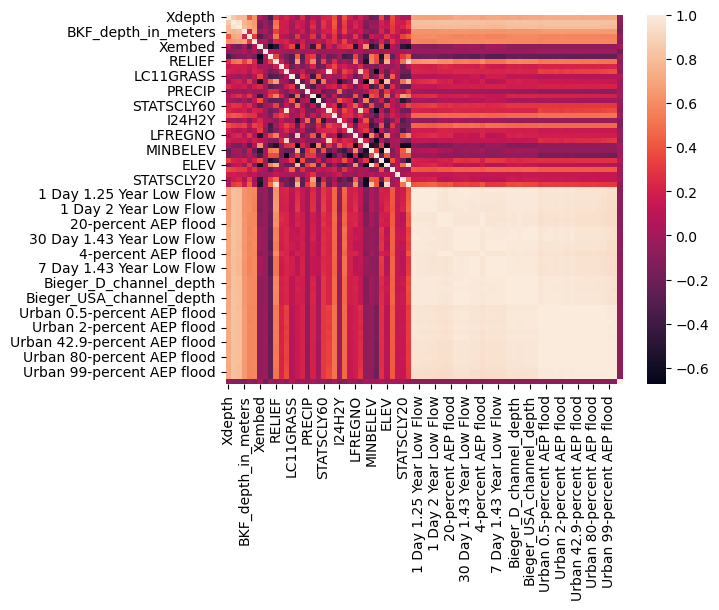

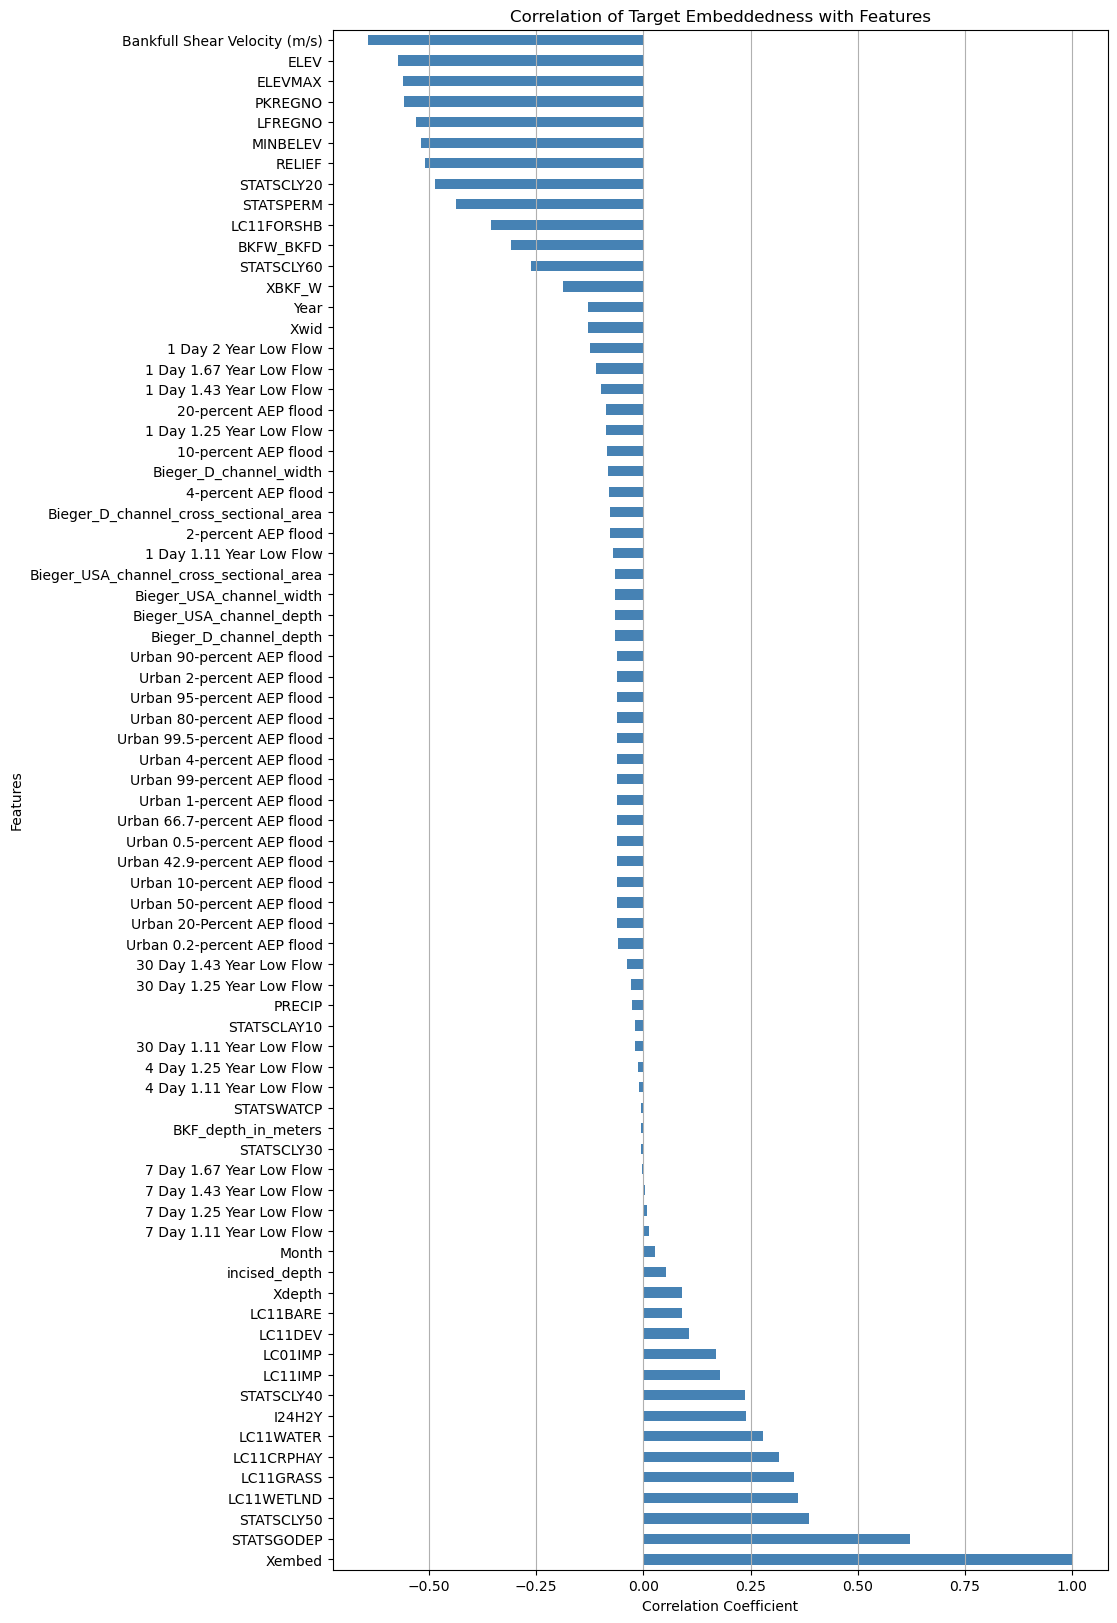

In [15]:
# Create correlation matrix and heatmap

# Select for only numerical values
num_df = vadeq_strmsts_corr_df.select_dtypes(include='number')
corr = num_df.corr(method = 'spearman')
# Print correlation plot
sns.heatmap(corr)

# Select the target value row
target_corr = corr.loc['Xembed'].sort_values(ascending = False)

# Plot the horizontal bar plot
plt.figure(figsize=(10, 20))
target_corr.plot(kind='barh', color='steelblue')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.title(f'Correlation of Target Embeddedness with Features')
plt.grid(axis='x')
plt.show()

In [16]:
# Display correlation values
corr

,Xdepth,Xwid,XBKF_W,BKF_depth_in_meters,BKFW_BKFD,incised_depth,Xembed,Year,Bankfull Shear Velocity (m/s),RELIEF,STATSCLY30,LC01IMP,LC11GRASS,PKREGNO,STATSCLY40,PRECIP,STATSPERM,STATSCLY50,STATSCLY60,LC11IMP,STATSWATCP,I24H2Y,LC11WATER,LC11CRPHAY,LFREGNO,LC11DEV,STATSGODEP,MINBELEV,LC11FORSHB,LC11WETLND,ELEV,LC11BARE,STATSCLAY10,STATSCLY20,ELEVMAX,1 Day 1.11 Year Low Flow,1 Day 1.25 Year Low Flow,1 Day 1.43 Year Low Flow,1 Day 1.67 Year Low Flow,1 Day 2 Year Low Flow,10-percent AEP flood,2-percent AEP flood,20-percent AEP flood,30 Day 1.11 Year Low Flow,30 Day 1.25 Year Low Flow,30 Day 1.43 Year Low Flow,4 Day 1.11 Year Low Flow,4 Day 1.25 Year Low Flow,4-percent AEP flood,7 Day 1.11 Year Low Flow,7 Day 1.25 Year Low Flow,7 Day 1.43 Year Low Flow,7 Day 1.67 Year Low Flow,Bieger_D_channel_cross_sectional_area,Bieger_D_channel_depth,Bieger_D_channel_width,Bieger_USA_channel_cross_sectional_area,Bieger_USA_channel_depth,Bieger_USA_channel_width,Urban 0.2-percent AEP flood,Urban 0.5-percent AEP flood,Urban 1-percent AEP flood,Urban 10-percent AEP flood,Urban 2-percent AEP flood,Urban 20-Percent AEP flood,Urban 4-percent AEP flood,Urban 42.9-percent AEP flood,Urban 50-percent AEP flood,Urban 66.7-percent AEP flood,Urban 80-percent AEP flood,Urban 90-percent AEP flood,Urban 95-percent AEP flood,Urban 99-percent AEP flood,Urban 99.5-percent AEP flood,Month
Xdepth,1.000000,0.845128,0.783571,0.777783,0.416337,0.626969,0.088963,-0.091350,-0.344404,0.257188,0.141562,0.223266,0.096971,-0.029836,0.243342,-0.095667,0.097105,0.033630,0.209607,0.228199,0.378317,0.042562,0.393829,0.177463,0.022166,0.180331,0.037992,-0.222760,-0.177731,0.350604,-0.116414,0.361324,0.174343,0.050625,0.070581,0.694801,0.689146,0.683449,0.678201,0.671527,0.682380,0.686060,0.681380,0.721118,0.718498,0.714486,0.709258,0.705747,0.684836,0.712864,0.708395,0.705942,0.703542,0.704522,0.714794,0.697958,0.714496,0.714593,0.714617,0.715856,0.719452,0.719552,0.719263,0.719849,0.719010,0.719587,0.718854,0.718506,0.718945,0.719498,0.719458,0.717746,0.716228,0.715169,-0.040093
Xwid,0.845128,1.000000,0.954775,0.753579,0.714981,0.653006,-0.128705,-0.045462,-0.194213,0.495210,0.183823,0.186744,0.014445,0.165694,0.155369,-0.031223,0.207150,-0.011917,0.283031,0.183945,0.419441,-0.007075,0.334607,0.102379,0.197662,0.141818,-0.130705,-0.030570,-0.055801,0.208650,0.105397,0.342377,0.181035,0.157074,0.312771,0.811633,0.810314,0.808575,0.806915,0.804303,0.812001,0.812392,0.811229,0.814757,0.814690,0.814230,0.806633,0.804921,0.812455,0.802939,0.800653,0.800564,0.800314,0.818284,0.818779,0.816343,0.818889,0.818984,0.818937,0.811175,0.816930,0.817262,0.816155,0.818508,0.815270,0.817649,0.814521,0.813948,0.814113,0.815389,0.814228,0.811290,0.807543,0.805883,-0.084797
XBKF_W,0.783571,0.954775,1.000000,0.791798,0.735887,0.669333,-0.187486,-0.022883,-0.113440,0.531421,0.187733,0.164630,-0.033799,0.202435,0.130771,-0.032252,0.264445,-0.061842,0.274663,0.162259,0.397372,-0.028171,0.301113,0.054618,0.231136,0.131927,-0.182006,-0.001665,-0.014766,0.174413,0.143555,0.303948,0.161040,0.216538,0.351819,0.793210,0.793600,0.793207,0.793094,0.792136,0.793474,0.792925,0.793036,0.792704,0.793390,0.794226,0.783417,0.782351,0.793251,0.778120,0.776496,0.777167,0.777614,0.801213,0.801509,0.799407,0.801712,0.801784,0.801709,0.795157,0.801033,0.801389,0.800629,0.802394,0.799948,0.801639,0.799475,0.799012,0.799424,0.800451,0.799739,0.797172,0.794112,0.792685,-0.104193
BKF_depth_in_meters,0.777783,0.753579,0.791798,1.000000,0.215064,0.705206,-0.006241,0.048145,-0.116216,0.327305,0.175804,0.187399,0.027827,0.045529,0.181473,-0.070630,0.151596,0.017238,0.174061,0.192730,0.334689,0.076576,0.332622,0.120010,0.084223,0.158000,-0.028851,-0.129404,-0.098209,0.222548,-0.022489,0.302984,0.164433,0.047336,0.160452,0.630490,0.626977,0.623561,0.621056,0.617092,0.633715,0.637803,0.631534,0.646475,0.643890,0.641563,0.633932,0.631088,0.636154,0.635335,0.631543,0.630293,0.629188,0.642540,0.646719,0.638972,0.646391,0.646785,0.6464

#### Major Takeaways:
1. The flow statistics seem to have little to no direct correlation to embeddedness.
2. Elevation again showed potential.
3. The soil statistics show a *lot* of potential!! These are denoted by a beginning "STAT" string.
4. The STATSGODEP shows the highest correlation (above 0.6)
5. The flow region numbers also looked higher.

#### What will we do with this information:
Since we are expecting some colinearity between feature sets, let's pick the top 40 correlations and see if we can select 10-20 features from that set.

In [17]:
# Sort values in correlation matrix
target_corr_abs = target_corr.abs()
target_corr_abs = target_corr_abs.sort_values(ascending = False)

# Pick top 40 from the series
top_corr = target_corr_abs[0:40]
top_corr

Xembed                                   1.000000
Bankfull Shear Velocity (m/s)            0.642673
STATSGODEP                               0.621255
ELEV                                     0.573023
ELEVMAX                                  0.560759
PKREGNO                                  0.557210
LFREGNO                                  0.529201
MINBELEV                                 0.517467
RELIEF                                   0.508661
STATSCLY20                               0.485593
STATSPERM                                0.437979
STATSCLY50                               0.387115
LC11WETLND                               0.359327
LC11FORSHB                               0.354635
LC11GRASS                                0.349978
LC11CRPHAY                               0.316427
BKFW_BKFD                                0.309219
LC11WATER                                0.278043
STATSCLY60                               0.262967
I24H2Y                                   0.239463


In [18]:
# Turn identified features into a list
selected_features = top_corr.index.tolist()

# Select correlation matrix for only selected_features
filtered_corr1 = corr.loc[selected_features, selected_features]

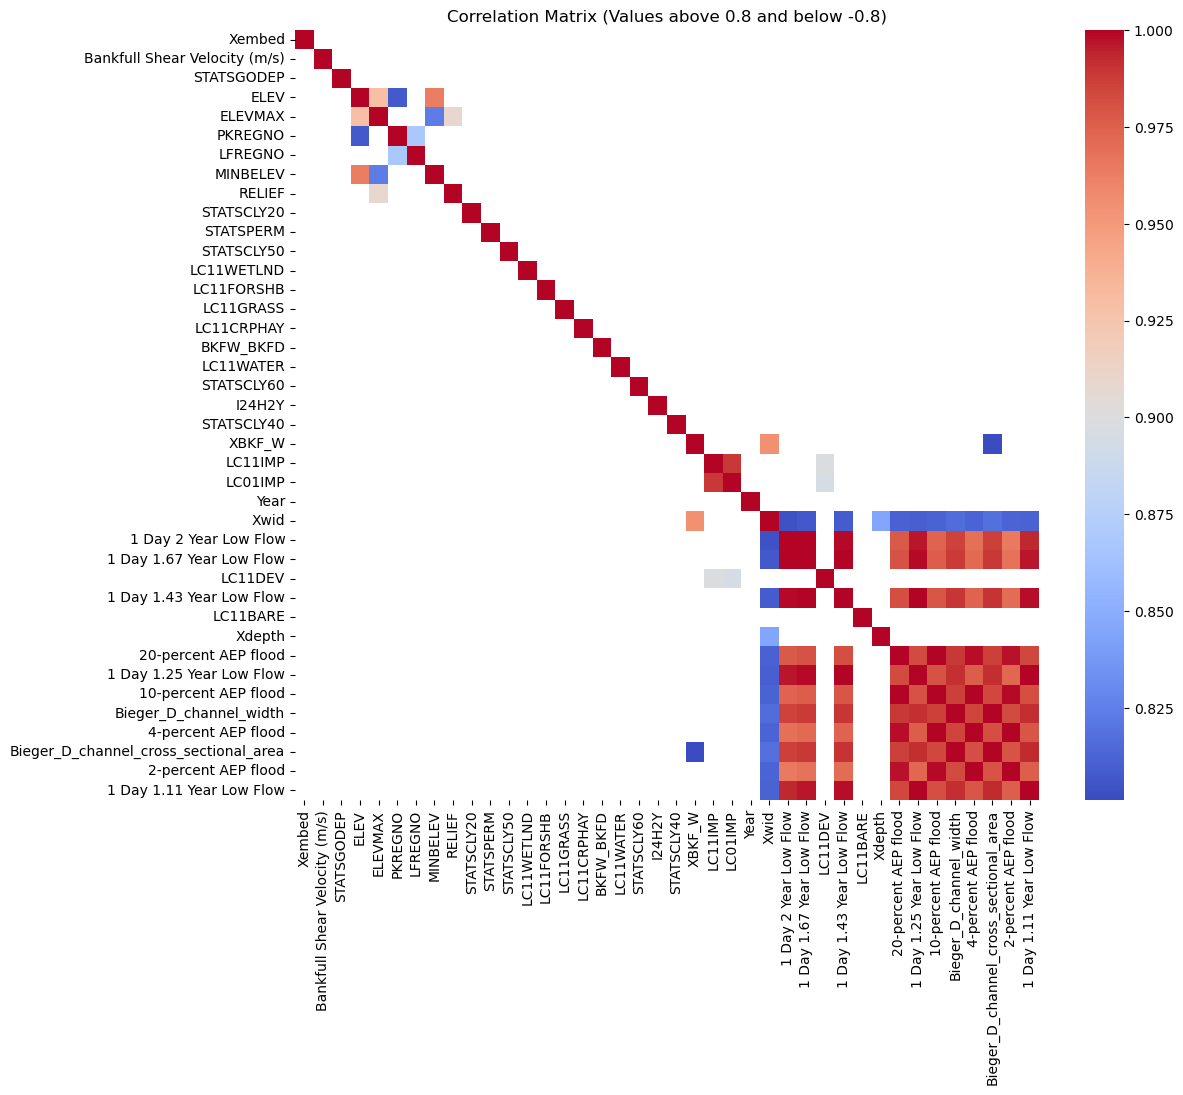

,Xembed,Bankfull Shear Velocity (m/s),STATSGODEP,ELEV,ELEVMAX,PKREGNO,LFREGNO,MINBELEV,RELIEF,STATSCLY20,STATSPERM,STATSCLY50,LC11WETLND,LC11FORSHB,LC11GRASS,LC11CRPHAY,BKFW_BKFD,LC11WATER,STATSCLY60,I24H2Y,STATSCLY40,XBKF_W,LC11IMP,LC01IMP,Year,Xwid,1 Day 2 Year Low Flow,1 Day 1.67 Year Low Flow,LC11DEV,1 Day 1.43 Year Low Flow,LC11BARE,Xdepth,20-percent AEP flood,1 Day 1.25 Year Low Flow,10-percent AEP flood,Bieger_D_channel_width,4-percent AEP flood,Bieger_D_channel_cross_sectional_area,2-percent AEP flood,1 Day 1.11 Year Low Flow
Xembed,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bankfull Shear Velocity (m/s),NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATSGODEP,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ELEV,NaN,NaN,NaN,1.000000,0.928574,0.807650,NaN,0.963489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ELEVMAX,NaN,NaN,NaN,0.928574,1.000000,NaN,NaN,0.823286,0.909053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PKREGNO,NaN,NaN,NaN,0.807650,NaN,1.000000,0.868712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LFREGNO,NaN,NaN,NaN,NaN,NaN,0.868712,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MINBELEV,NaN,NaN,NaN,0.963489,0.823286,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RELIEF,NaN,NaN,NaN,NaN,0.909053,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATSCLY20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Let's make a heatmap of correlation values above/below 0.8 to check for interdependency

# Filter correlation matrix for values above 0.8 and below -0.8
high_corr1 = filtered_corr1[(filtered_corr1 > 0.8) | (filtered_corr1 < -0.8)]

# Create heatmap for filtered matrix
plt.figure(figsize=(12,10))
sns.heatmap(high_corr1,
            cmap = 'coolwarm')
plt.title('Correlation Matrix (Values above 0.8 and below -0.8)')
plt.show()

# Print correlation values
high_corr1

#### Takeaways:
1. Only select ELEV (remove other elevation variables)
6. Pick one flood --> 20-percent AEP flood
7. Pick out one depth --> Bieger_USE_channel_depth
8. Take out low flows

In [20]:
# Remove first few columns and rows of interest
high_corr2 = filtered_corr1.drop(index = ['ELEVMAX',
                                  'MINBELEV',
                                    'LFREGNO',
                                   '10-percent AEP flood',
                                   '1 Day 2 Year Low Flow',
                                   'Bieger_D_channel_width',
                                    '4-percent AEP flood',
                                   '2-percent AEP flood',
                                    '1 Day 1.67 Year Low Flow',
                                    'LC11DEV',
                                    '1 Day 1.43 Year Low Flow'],
                           columns = ['ELEVMAX',
                                  'MINBELEV',
                                    'LFREGNO',
                                   '10-percent AEP flood',
                                   '1 Day 2 Year Low Flow',
                                   'Bieger_D_channel_width',
                                    '4-percent AEP flood',
                                   '2-percent AEP flood',
                                    '1 Day 1.67 Year Low Flow',
                                    'LC11DEV',
                                    '1 Day 1.43 Year Low Flow'])

In [21]:
# Display new correlation matrix
high_corr2

,Xembed,Bankfull Shear Velocity (m/s),STATSGODEP,ELEV,PKREGNO,RELIEF,STATSCLY20,STATSPERM,STATSCLY50,LC11WETLND,LC11FORSHB,LC11GRASS,LC11CRPHAY,BKFW_BKFD,LC11WATER,STATSCLY60,I24H2Y,STATSCLY40,XBKF_W,LC11IMP,LC01IMP,Year,Xwid,LC11BARE,Xdepth,20-percent AEP flood,1 Day 1.25 Year Low Flow,Bieger_D_channel_cross_sectional_area,1 Day 1.11 Year Low Flow
Xembed,1.000000,-0.642673,0.621255,-0.573023,-0.557210,-0.508661,-0.485593,-0.437979,0.387115,0.359327,-0.354635,0.349978,0.316427,-0.309219,0.278043,-0.262967,0.239463,0.236474,-0.187486,0.178365,0.168175,-0.129586,-0.128705,0.089040,0.088963,-0.087555,-0.086428,-0.077408,-0.071127
Bankfull Shear Velocity (m/s),-0.642673,1.000000,-0.390215,0.549386,0.432657,0.342953,0.310526,0.316312,-0.253143,-0.534852,0.375789,-0.322641,-0.324482,-0.026375,-0.376574,0.066224,-0.006368,-0.306377,-0.113440,-0.202894,-0.189295,0.100339,-0.194213,-0.253960,-0.344404,-0.204471,-0.200077,-0.223125,-0.212978
STATSGODEP,0.621255,-0.390215,1.000000,-0.609976,-0.650837,-0.541656,-0.627022,-0.563442,0.570368,0.303291,-0.458983,0.300274,0.300609,-0.290829,0.220469,-0.246709,0.411293,0.213850,-0.182006,0.270532,0.261232,-0.062461,-0.130705,0.043761,0.037992,-0.135712,-0.141575,-0.124983,-0.124322
ELEV,-0.573023,0.549386,-0.609976,1.000000,0.807650,0.735129,0.504308,0.497394,-0.308656,-0.606794,0.415328,-0.259748,-0.170184,0.287666,-0.343301,0.364983,-0.263746,-0.349857,0.143555,-0.249713,-0.227267,0.027585,0.105397,-0.097138,-0.116414,0.183645,0.199476,0.150245,0.178263
PKREGNO,-0.557210,0.432657,-0.650837,0.807650,1.000000,0.674124,0.503927,0.489379,-0.455788,-0.606024,0.281645,-0.307303,-0.118531,0.300681,-0.258421,0.517234,-0.522939,-0.280743,0.202435,-0.057989,-0.036012,0.023396,0.165694,-0.094724,-0.029836,0.220402,0.246141,0.198513,0.221814
RELIEF,-0.508661,0.342953,-0.541656,0.735129,0.674124,1.000000,0.491003,0.572875,-0.252601,-0.391341,0.362986,-0.286711,-0.105157,0.528369,0.009621,0.331944,-0.080064,-0.199644,0.531421,-0.120569,-0.102135,0.014906,0.495210,0.043517,0.257188,0.615193,0.624980,0.587418,0.610278
STATSCLY20,-0.485593,0.310526,-0.627022,0.504308,0.503927,0.491003,1.000000,0.690318,-0.491171,-0.206702,0.390941,-0.310085,-0.343865,0.335312,-0.203483,0.169890,-0.307903,-0.258506,0.216538,-0.195543,-0.176923,0.005038,0.157074,-0.022609,0.050625,0.103025,0.182956,0.154165,0.167226
STATSPERM,-0.437979,0.316312,-0.563442,0.497394,0.489379,0.572875,0.690318,1.000000,-0.573292,-0.208975,0.307196,-0.413074,-0.215883,0.288367,-0.159502,0.124681,-0.237304,-0.328596,0.264445,-0.177102,-0.160274,0.041898,0.207150,-0.082119,0.097105,0.177076,0.242218,0.213481,0.227034
STATSCLY50,0.387115,-0.253143,0.570368,-0.308656,-0.455788,-0.252601,-0.491171,-0.573292,1.000000,0.168722,-0.101038,0.401714,0.173849,-0.127725,0.231251,-0.298601,0.415044,0.035767,-0.061842,0.041518,0.036157,-0.048843,-0.011917,0.121070,0.033630,0.068089,0.023896,0.038146,0.037996
LC11WETLND,0.359327,-0.534852,0.303291,-0.606794,-0.606024,-0.391341,-0.206702,-0.208975,0.168722,1.000000,-0.261188,0.324077,0.133555,0.023721,0.391985,-0.201442,0.114499,0.375332,0.174413,0.109647,0.086869,-0.044693,0.208650,0.373918,0.350604,0.195440,0.192989,0.243528,0.209765


#### Before we move forward, we will look at the features within the Excel sheet and identify variables of interest based on our physical understanding of embeddedness.

#### Identifed features from StreamStats engine:
1. RELIEF
2. I24H2Y
3. DRNAREA
4. ELEV

#### The final features were selected based on correlations and physical understandings of sediment transport

In [22]:
# Add LAT/LON
vadeq_strmsts = vadeq_strmsts.merge(coords,
                                 on = 'StationID',
                                 how = 'left')

In [23]:
# Select final columns from vdeqstreamstats
vadeq_strmsts = vadeq_strmsts[['StationID',
                               'Date', 'Month',
                               'LATITUDE', 'LONGITUDE',
                               'Bankfull Shear Velocity (m/s)',
                             'Xembed',
                             'STATSGODEP',
                             'ELEV',
                             'STATSCLY20',
                             'RELIEF',
                             'STATSPERM',
                             'STATSCLY50',
                             'LC11FORSHB',
                             'LC11CRPHAY',
                             'I24H2Y', 
                             'PRECIP',
                             'Year',
                             'DRNAREA',
                               'PKREGNO',
                                'Month']]

### 2c. Create scatterplots against target

Let's plot each feature set against the target to look for obvious red flags.

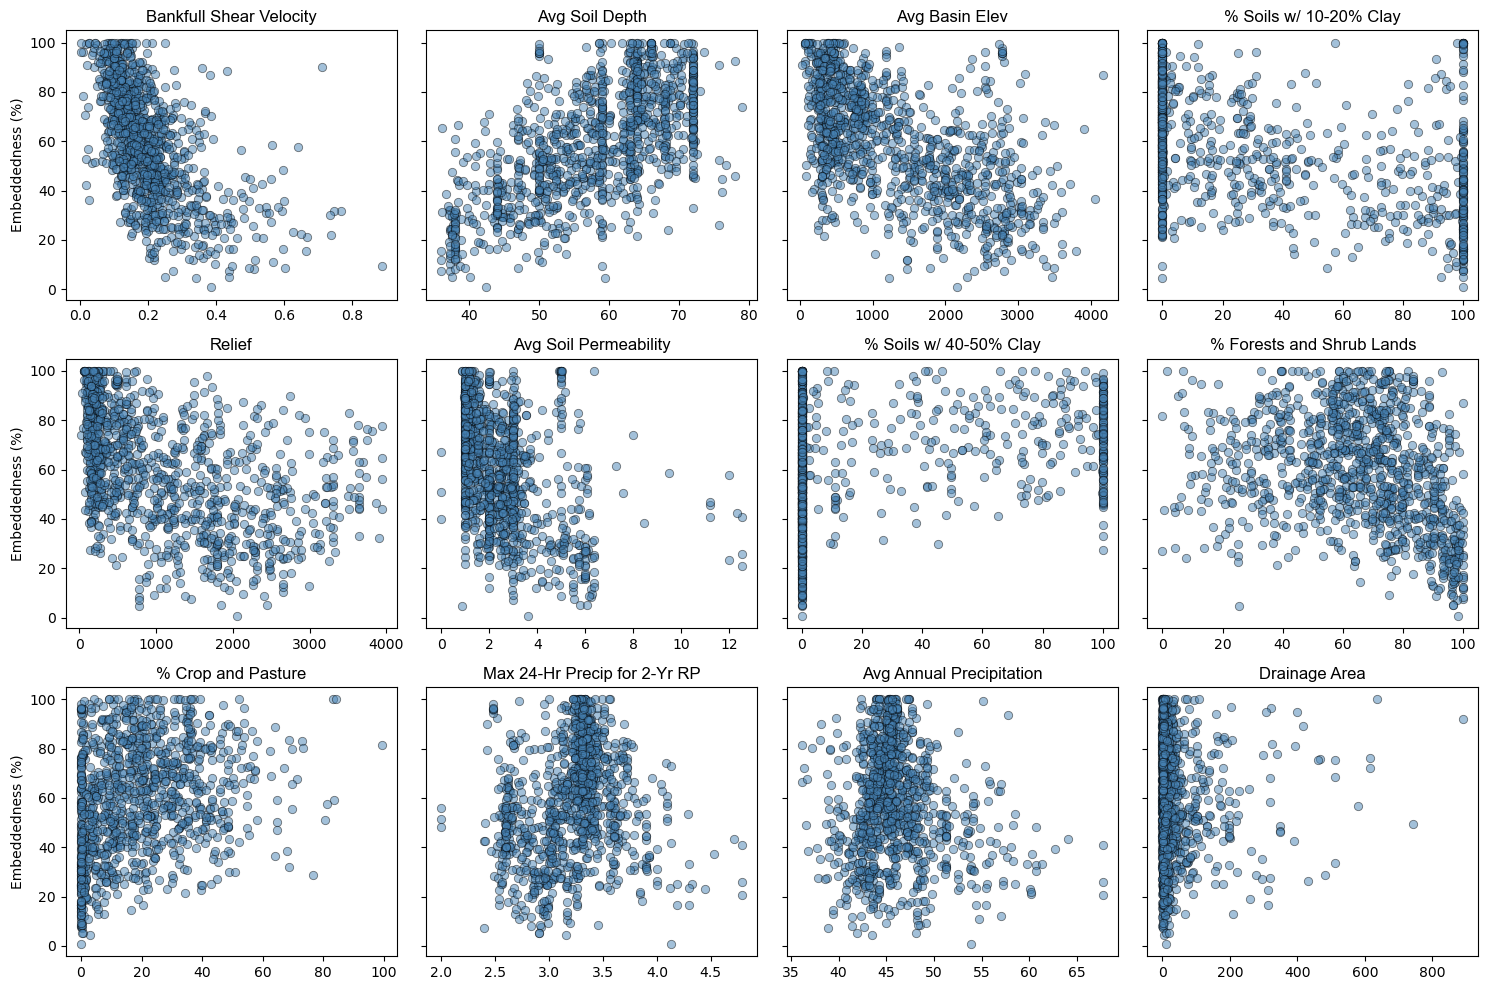

In [24]:
# Set up a 3x4 grid of scatter plots

# Define new df for plotting 
sc_df = vadeq_strmsts[[ 'Xembed', 'Bankfull Shear Velocity (m/s)', 'STATSGODEP', 'ELEV',
                       'STATSCLY20', 'RELIEF', 'STATSPERM', 'STATSCLY50', 'LC11FORSHB',
                       'LC11CRPHAY', 'I24H2Y', 'PRECIP', 'DRNAREA']]
sc_df = sc_df.rename(columns = {'Xembed':'Streambed Embeddedness (%)',
                                'Bankfull Shear Velocity (m/s)':'Bankfull Shear Velocity',
                                'STATSGODEP':'Avg Soil Depth', 
                                'ELEV':'Avg Basin Elev',
                                'STATSCLY20':'% Soils w/ 10-20% Clay', 
                                'RELIEF':'Relief', 
                                'STATSPERM':'Avg Soil Permeability', 
                                'STATSCLY50':'% Soils w/ 40-50% Clay', 
                                'LC11FORSHB':'% Forests and Shrub Lands',
                                'LC11CRPHAY':'% Crop and Pasture', 
                                'I24H2Y':'Max 24-Hr Precip for 2-Yr RP', 
                                'PRECIP':'Avg Annual Precipitation', 
                                'DRNAREA':'Drainage Area'})
num_features = ['Bankfull Shear Velocity',
               'Avg Soil Depth', 'Avg Basin Elev', '% Soils w/ 10-20% Clay', 'Relief',
               'Avg Soil Permeability', '% Soils w/ 40-50% Clay',
               '% Forests and Shrub Lands', '% Crop and Pasture',
               'Max 24-Hr Precip for 2-Yr RP', 'Avg Annual Precipitation',
               'Drainage Area']

fig, axes = plt.subplots(3, 4, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for i, feature in enumerate(num_features):
    ax = axes[i]
    sns.scatterplot(x=sc_df[feature], y=sc_df['Streambed Embeddedness (%)'], 
                    color='steelblue', edgecolor='black', linewidth=0.6, alpha = 0.5, ax=ax)
    ax.set_title(feature, fontsize=12, fontname = 'Arial')
    ax.set_xlabel("")  # Remove x-axis labels
    ax.set_ylabel("Embeddedness (%)" if i % 4 == 0 else "")  # Y-axis label only on the first column

# Remove any unused subplots
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

# Save plot
sctr_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'va_feat_scatter_grid.png')
plt.savefig(sctr_path, dpi = 300)

# Show plot
plt.show()

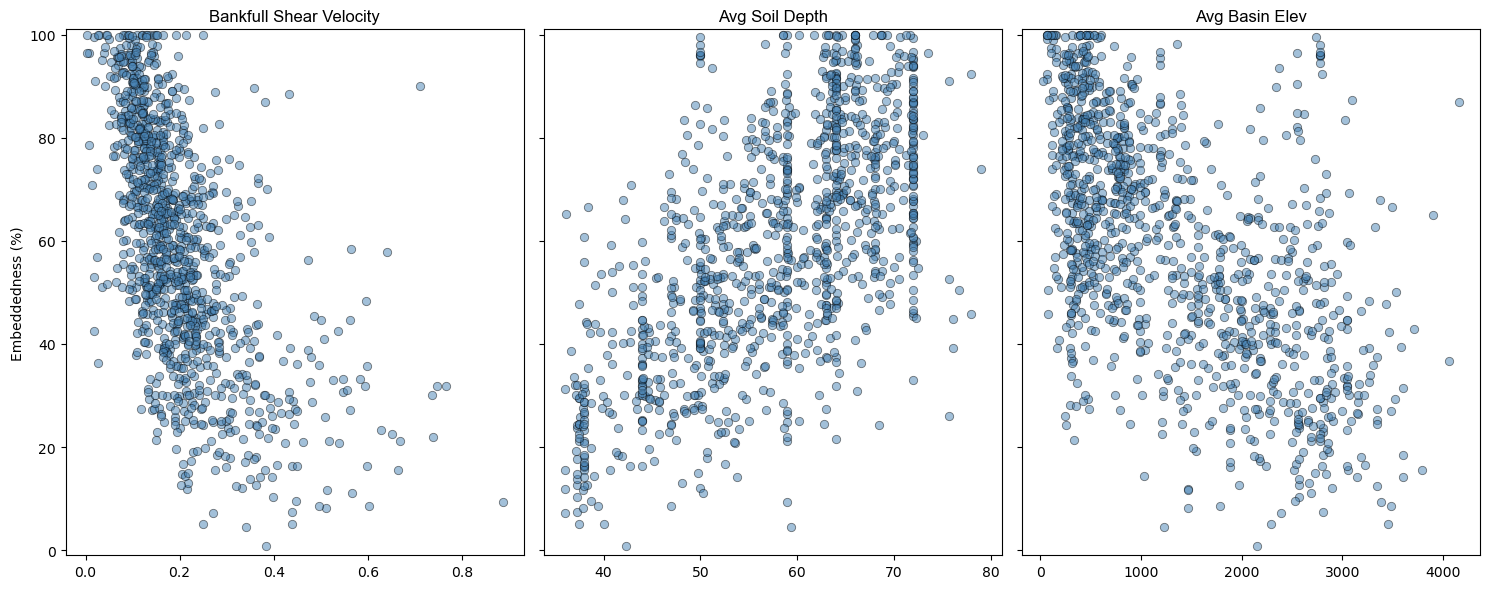

In [45]:
# Additional plotting required for paper

# Define new df for plotting top three correlations
sc_tri_df = vadeq_strmsts[[ 'Xembed', 'Bankfull Shear Velocity (m/s)', 'STATSGODEP', 'ELEV']]
sc_tri_df = sc_df.rename(columns = {'Xembed':'Streambed Embeddedness (%)',
                                'Bankfull Shear Velocity (m/s)':'Bankfull Shear Velocity',
                                'STATSGODEP':'Avg Soil Depth', 
                                'ELEV':'Avg Basin Elev'})
num_features = ['Bankfull Shear Velocity',
               'Avg Soil Depth', 'Avg Basin Elev']

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
axes = axes.flatten()

for i, feature in enumerate(num_features):
    ax = axes[i]
    sns.scatterplot(x=sc_df[feature], y=sc_df['Streambed Embeddedness (%)'], 
                    color='steelblue', edgecolor='black', linewidth=0.6, alpha = 0.5, ax=ax)
    ax.set_title(feature, fontsize=12, fontname = 'Arial')
    ax.set_xlabel("")  # Remove x-axis labels
    ax.set_ylabel("Embeddedness (%)")
    plt.ylim([-1, 101])

# Remove any unused subplots
for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

# Save plot
sctr_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'va_top_three_corr_scatter.png')
plt.savefig(sctr_path, dpi = 300)

# Show plot
plt.show()

#### Required plotting for Paper

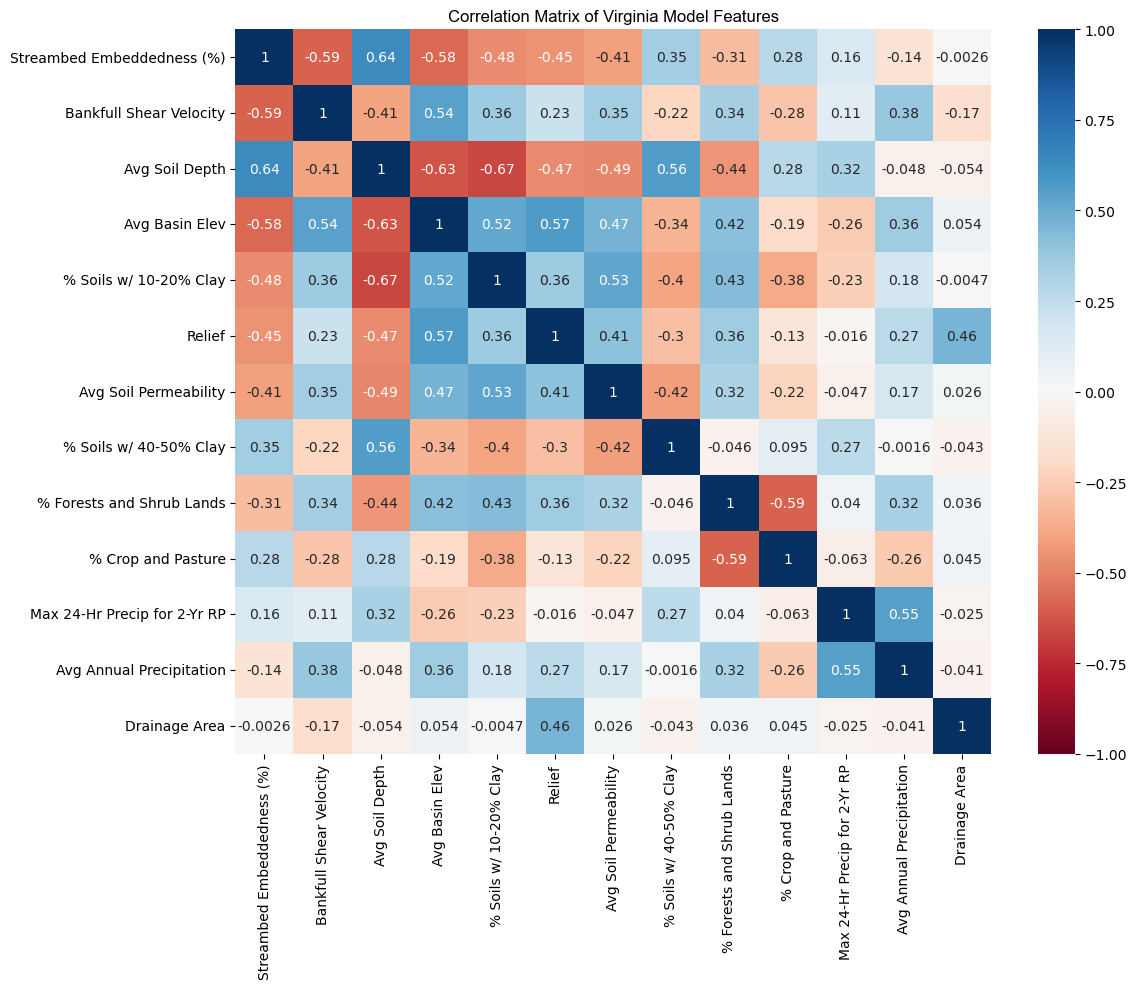

In [26]:
# Create correlation matrix
overall_corr = sc_df.corr()

# Create heatmap
plt.figure(figsize=(12,10))
sns.heatmap(overall_corr,
            cmap = 'RdBu',
           annot = True,
           vmin = -1, vmax = 1)
plt.title('Correlation Matrix of Virginia Model Features', fontname = 'Arial')
plt.tight_layout()

# Save plot
corr_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'va_corr_matrix.png')
plt.savefig(corr_path, dpi = 300)

# Show plot
plt.show()

### Step 2d. Power-Law Fit for Later Model Comparison

In [27]:
# Define the power-law function
def power_law(x, alpha, beta):
    return beta * np.power(x, alpha)

# Filter the data
filtered_data = sc_df[sc_df['Bankfull Shear Velocity']>0.1]
filtered_data = filtered_data[filtered_data['Streambed Embeddedness (%)']!=0]

# Extract the independent and dependent variables
x_data = filtered_data['Bankfull Shear Velocity']
y_data = filtered_data['Streambed Embeddedness (%)']

# Fit the power-law model
popt, pcov = curve_fit(power_law, x_data, y_data)

# Extract the optimal parameters
alpha_opt, beta_opt = popt
print(f"Optimal alpha: {alpha_opt}")
print(f"Optimal beta: {beta_opt}")

# Apply conditional prediction: use model where u* >= 0.1, otherwise assign 100
predicted_Xembed_all = np.where(
    sc_df['Bankfull Shear Velocity'] >= 0.1,
    power_law(sc_df['Bankfull Shear Velocity'], alpha_opt, beta_opt),
    100
)

# Calculate R-squared
residuals = sc_df['Streambed Embeddedness (%)'] - predicted_Xembed_all
ss_res = np.sum(residuals**2)
ss_tot = np.sum((sc_df['Streambed Embeddedness (%)'] - np.mean(sc_df['Streambed Embeddedness (%)']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R-squared: {r_squared}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(sc_df['Streambed Embeddedness (%)'], predicted_Xembed_all))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate MAE
mae = mean_absolute_error(sc_df['Streambed Embeddedness (%)'], predicted_Xembed_all)
print(f"Mean Absolute Error (MAE): {mae}")

# Sort values for cleaner plotting
sorted_indices = sc_df['Bankfull Shear Velocity'].argsort()
sorted_u = sc_df['Bankfull Shear Velocity'].values[sorted_indices]
sorted_pred = predicted_Xembed_all[sorted_indices]
beta_round = round(beta_opt, 2)
alpha_round = round(alpha_opt, 2)

Optimal alpha: -0.6000566975415557
Optimal beta: 20.558121212309043
R-squared: 0.3320404969776538
Root Mean Squared Error (RMSE): 18.595783268331076
Mean Absolute Error (MAE): 14.72223462903451


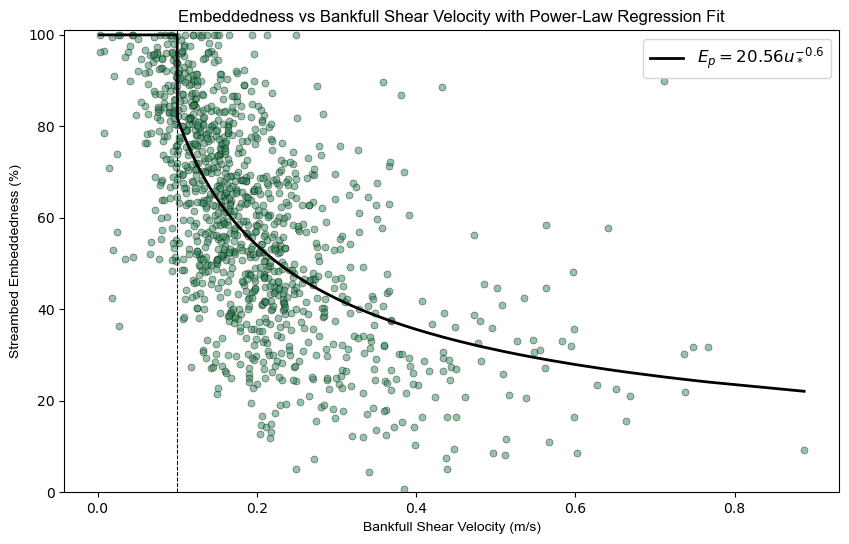

In [28]:
# Plot power-law fit using u*
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Bankfull Shear Velocity', y='Streambed Embeddedness (%)', data=sc_df, edgecolor = 'k', linewidth = 0.5, color = 'seagreen', alpha = 0.5, s = 25)
plt.plot(sorted_u, sorted_pred, color="black", label=rf'$E_p = {beta_round} u_*^{{{alpha_round}}}$', linewidth = 2)
plt.axvline(x=0.1, color='k', linestyle='--', linewidth = 0.75)
plt.ylim(0, 101)
plt.xlabel('Bankfull Shear Velocity (m/s)', fontname = 'Arial')
plt.ylabel('Streambed Embeddedness (%)', fontname = 'Arial')
plt.title('Embeddedness vs Bankfull Shear Velocity with Power-Law Regression Fit', fontname = 'Arial')
plt.legend(fontsize = 12)

# Save to results folder
powerlaw_path = os.path.join(BASE_DIR, "virginia_streamstats", "eda", "figures", "va_power_law.png")
plt.savefig(powerlaw_path, dpi = 300)

# Show plot
plt.show()


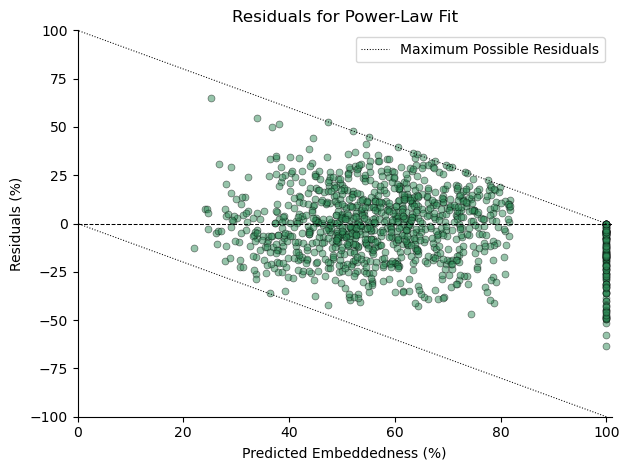

In [29]:
# Plot residuals of power-law fit
plt.scatter(predicted_Xembed_all, residuals, edgecolor = 'k', linewidth = 0.5, color = 'seagreen', alpha = 0.5, s = 25)
plt.xlabel('Predicted Embeddedness (%)')
plt.ylabel('Residuals (%)')
plt.title("Residuals for Power-Law Fit")
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.75)
plt.ylim([-100, 100])
plt.xlim([0, 101])
ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot boundaries
plt.plot([100, 0], [0, 100],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75,
        label = 'Maximum Possible Residuals')
plt.plot([100, 0], [-100, 0],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
plt.tight_layout()
plt.legend()

# Save plot
powerlaw_path = os.path.join(BASE_DIR, "virginia_streamstats", "eda", "figures", "va_power_residuals.png")
plt.savefig(powerlaw_path, dpi = 300)

# Show plot
plt.show()

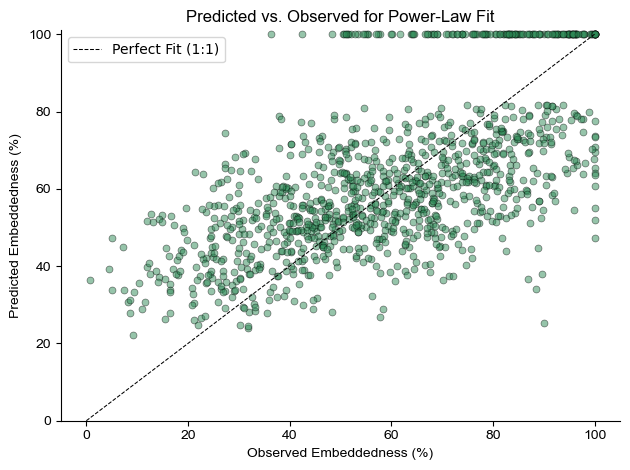

In [30]:
# Plot predictions vs true for power law
plt.scatter(sc_df['Streambed Embeddedness (%)'], # observed vals
            predicted_Xembed_all, # predictions
            color = 'seagreen',
            s = 25,
            edgecolors = 'black',
            linewidths = 0.5,
           alpha = 0.5)
plt.xlabel('Observed Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.title('Predicted vs. Observed for Power-Law Fit', fontname = 'Arial')
plt.ylim([0, 101])
ax = plt.gca()
ax.set_facecolor("white")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.plot([0, 100], [0, 100], # plot 'perfect' fit
         color = 'k',
         linestyle = '--',
         linewidth = 0.75,
        label = 'Perfect Fit (1:1)')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
plt.tight_layout()
plt.legend()

# Save to results folder
powerlaw_path = os.path.join(BASE_DIR, "virginia_streamstats", "eda", "figures", "va_power_predict_true.png")
plt.savefig(powerlaw_path, dpi = 300)

# Show plot
plt.show()

In [31]:
# Add residuals to sc_df
power_corr = sc_df.copy().drop(columns = ['Streambed Embeddedness (%)', 'Bankfull Shear Velocity'])
power_corr['Residuals (%)'] = residuals

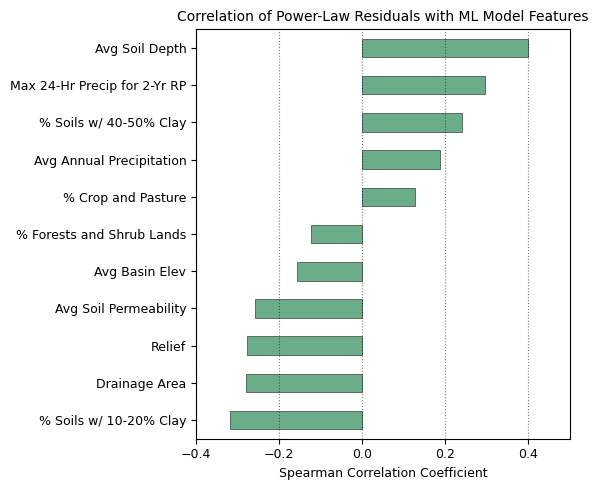

In [32]:
# Select for only numerical values
corr = power_corr.corr(method = 'spearman')

# Select for target
target_corr = corr.loc['Residuals (%)'].sort_values().drop('Residuals (%)')

# Plot the horizontal bar plot
plt.figure(figsize = (6, 5))
target_corr.plot(kind='barh', 
                 color='seagreen', 
                 fontsize = 9,
                alpha = 0.7,
                 edgecolor = 'k',
                linewidth = 0.5)
plt.xlabel('Spearman Correlation Coefficient', fontsize = 9)
plt.xlim([-0.4, 0.5])
plt.title(rf'Correlation of Power-Law Residuals with ML Model Features', fontsize = 10)
plt.grid(axis='x', which='both', linestyle = ':', color = 'k', alpha = 0.5)
plt.tight_layout()

# Save plot
powerlaw_path = os.path.join(BASE_DIR, 'virginia_streamstats', 'eda', 'figures', 'va_powerlaw_residual_corr.png')
plt.savefig(powerlaw_path, dpi = 600)

# Show plot
plt.show()

### 2d. Histograms

We will quickly check that the density of certain columns are valid.

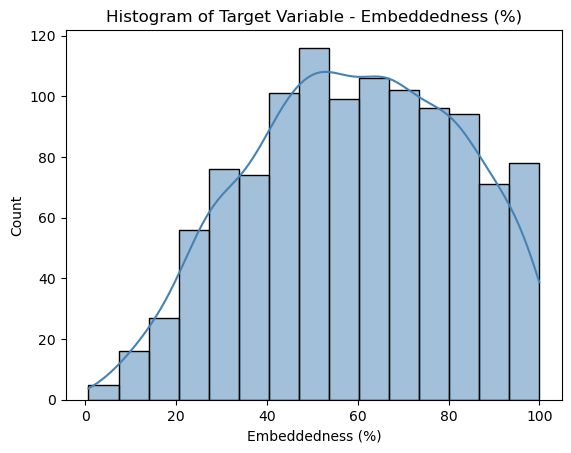

In [33]:
# Plot histogram of target variable
sns.histplot(vadeq_strmsts['Xembed'],
             color = 'steelblue',
             kde = True)
plt.xlabel('Embeddedness (%)')
plt.title('Histogram of Target Variable - Embeddedness (%)')

# Show plot
plt.show()

This is good! We don't see much visual bias in our target. It looks relatively normally distributed, if not a little left-skewed.

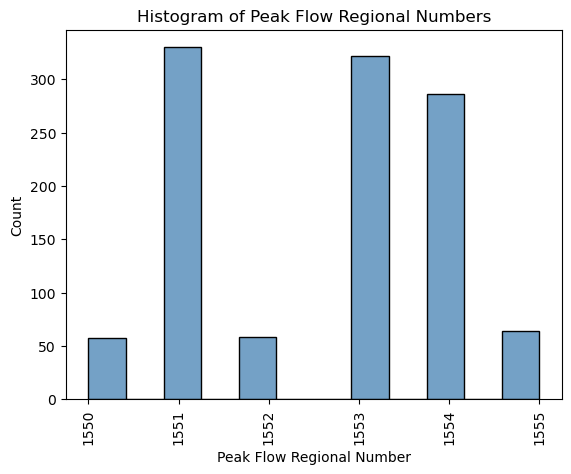

PKREGNO
1551    330
1553    322
1554    286
1555     64
1552     58
1550     57
Name: count, dtype: int64

In [34]:
# Plot histogram of Peak Flow Regional Number
sns.histplot(vadeq_strmsts['PKREGNO'],
            color = 'steelblue')
plt.xticks(rotation=90)
plt.xlabel('Peak Flow Regional Number')
plt.title('Histogram of Peak Flow Regional Numbers')
plt.show()

# Display counts for each peak flow region number
vadeq_strmsts['PKREGNO'].value_counts()

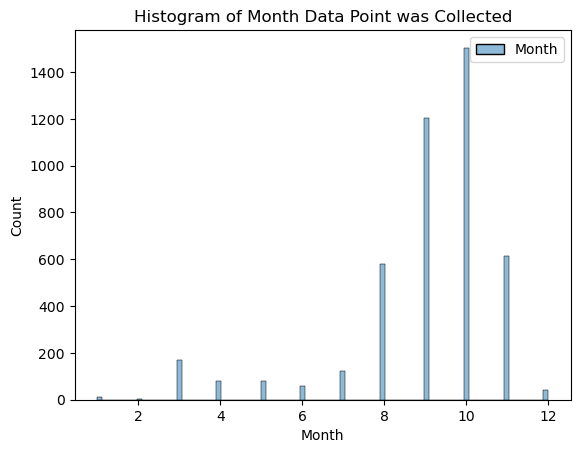

In [35]:
# Plot histogram of Month
sns.histplot(vadeq_strmsts['Month'],
            color = 'steelblue')
plt.xlabel('Month')
plt.title('Histogram of Month Data Point was Collected')

# Show plot
plt.show()

**From the histogram of month information above, we can see that stations are monitored almost exclusively during the fall. This is expected given the difficulty of monitoring during the colder months. Given this information, we're going to remove month from the model dataset.**

In [36]:
# Drop month from dataframe
vadeq_strmsts_trim1 = vadeq_strmsts.drop(columns = ['Month'])

In [37]:
# One hot encode PKREGNO using pandas
vadeq_strmsts_trim1.rename(columns = {'PKREGNO':'Peak Flow #'},
                                    inplace = True)
vadeq_strmsts_mdl = pd.get_dummies(vadeq_strmsts_trim1,
                                   columns = ['Peak Flow #'],
                                   prefix_sep = ': ',
                                  drop_first = True)

# Print dataset
vadeq_strmsts_mdl

,StationID,Date,LATITUDE,LONGITUDE,Bankfull Shear Velocity (m/s),Xembed,STATSGODEP,ELEV,STATSCLY20,RELIEF,STATSPERM,STATSCLY50,LC11FORSHB,LC11CRPHAY,I24H2Y,PRECIP,Year,DRNAREA,Peak Flow #: 1551,Peak Flow #: 1552,Peak Flow #: 1553,Peak Flow #: 1554,Peak Flow #: 1555
0,1AACO006.10,2006-11-21,38.728611,-77.203333,0.147072,62.545455,70.48,148.98,0.00,171.0,2.895,0.00,16.23,0.00,3.140,43.078,2006,0.0702,True,False,False,False,False
1,1AACO004.84,2008-06-25,38.720500,-77.190722,0.211670,51.636364,66.65,308.44,51.85,451.0,2.395,0.00,22.49,0.11,3.167,43.888,2008,40.5000,False,False,False,False,False
2,1AACO006.10,2008-06-26,38.728611,-77.203333,0.129573,56.818182,70.48,148.98,0.00,171.0,2.895,0.00,16.23,0.00,3.140,43.078,2008,0.0702,True,False,False,False,False
3,1AACO009.14,2008-06-26,38.761944,-77.207222,0.130071,63.454545,66.39,324.56,54.64,357.0,2.271,0.00,22.65,0.09,3.169,43.981,2008,36.3000,True,False,False,False,False
4,1AAUA017.60,2005-09-22,38.490361,-77.466389,0.161058,65.454545,56.77,317.16,0.30,278.0,1.506,0.00,67.67,7.74,3.055,43.317,2005,29.7000,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,2BXRK001.64,2022-10-26,37.811383,-78.729900,0.228096,67.090909,68.00,796.84,0.00,575.0,2.000,0.00,95.34,0.00,3.723,49.307,2022,0.7600,False,False,True,False,False
1113,2-JKS070.06,2022-09-12,38.123444,-79.779725,0.248010,27.636364,44.64,2821.90,69.18,2550.0,5.089,0.00,77.43,17.98,2.959,43.163,2022,104.0000,False,False,False,True,False
1114,4ASNA007.82,2022-09-20,36.792139,-79.112444,0.196710,95.909091,71.04,604.47,0.00,691.0,1.114,90.49,60.89,23.17,3.319,45.609,2022,79.9000,True,False,False,False,False
1115,8-MIC001.47,2022-10-25,37.753450,-77.720931,0.114323,89.090909,72.00,298.12,0.00,197.0,1.000,100.00,41.15,49.07,3.290,43.671,2022,5.6500,True,False,False,False,False


## Step 4. Export dataset

In [38]:
# Push to excel
vadeq_mdl_path = os.path.join(BASE_DIR, "data", "processed", "virginia", "vadeq_strmsts_after_eda.xlsx")
vadeq_strmsts_mdl.to_excel(vadeq_mdl_path)
print(f"Dataset saved to {vadeq_mdl_path}")

Dataset saved to C:\Users\reill\Documents\Virginia Tech\Czuba Research\Embeddedness\GitHub\Embeddedness_ML_XAI\data\processed\virginia\vadeq_strmsts_after_eda.xlsx


## Next Steps
Now we will move forward to model selection, evaluation, and deployment!